---
# **Instructions**
For this assignment, you will be using the data set car data.csv. This data set is a modified version of the data set imports-85.data from https://archive.ics.uci.edu/ml/datasets/automobile. There are two columns in this data set. One is the weight of the vehicle in pounds, and the other is the highway miles per gallon.

---

### **Assignment Setup**
Steps achieved in this section:
* Import Libraries
* Load Data
* Verify/Preview data

In [57]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [58]:
# Load the data file(s)
cars_df = pd.read_csv('https://raw.githubusercontent.com/dtavizondykstra/BU_Datasets/refs/heads/main/DSC320_MathForDataScience/car_data.csv')

In [59]:
# Verify Load of df
cars_df.head()

,weight,hwy_mpg
0,2548,27
1,2548,27
2,2823,26
3,2337,30
4,2824,22


In [60]:
# Define x and y once so they can be reused throughout
# the assignment
# x = predictor variable (weight)
# y = target variable (highway mpg)
# ---------------------------------------------------------
x = cars_df[["weight"]]
y = cars_df["hwy_mpg"]

---
# **Problem 1**
1. Make a scatterplot of the highway miles per gallon (y-axis) versus the weight (x-axis).

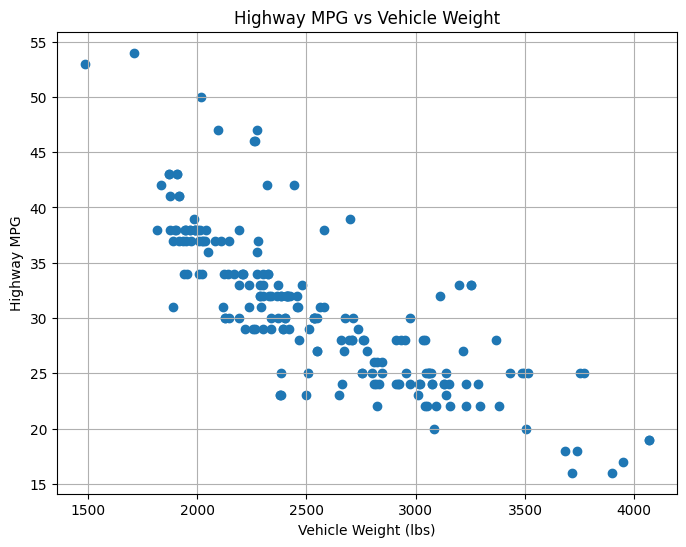

In [61]:
# Create scatterplot of highway mpg vs vehicle weight
plt.figure(figsize=(8, 6))
plt.scatter(x['weight'], y)

# Specify Graph Details
plt.xlabel("Vehicle Weight (lbs)")
plt.ylabel("Highway MPG")
plt.title("Highway MPG vs Vehicle Weight")
plt.grid(True)

# **Problem 2**
2. Based on your plot, what is the general trend of how highway miles per gallon varies with the weight?

**Answer:** Based on the scatterplot, there appears to be a negative relationship between vehicle weight and highway mpg. As vehicle weight increases, highway mpg generally decreases.


# **Problem 3**
3. If you were to build a linear model using this data to predict highway miles per gallon from weight,
would you expect the slope to be positive or negative? Explain.

**Answer:** I would expect the slope to be negative because the plot shows that heavier vehicles tend to have lower highway mpg.

# **Problem 4**
4. If the slope of a linear model predicting highway miles per gallon from the weight, interpret the meaning
of the slope being −0.05.

**Answer**: If the slope is -0.05, that means for every additional 1 pound of vehicle weight, the highway mpg decreases by 0.05 mpg on average. A simpler way to imagine this is for every 100 pounds of additional weight, the highway miles per gallon would decrease by approximately 5 mpg.

# **Problem 5**
5. Write code to add a line to the graph you made in problem (1). Adjust the slope and y-intercept of this line until you think you have found the line that best fits the data. Record the slope and y-intercept.

**Answer**
* `slope_guess = -0.006`
* `intercept_guess = 43.5`

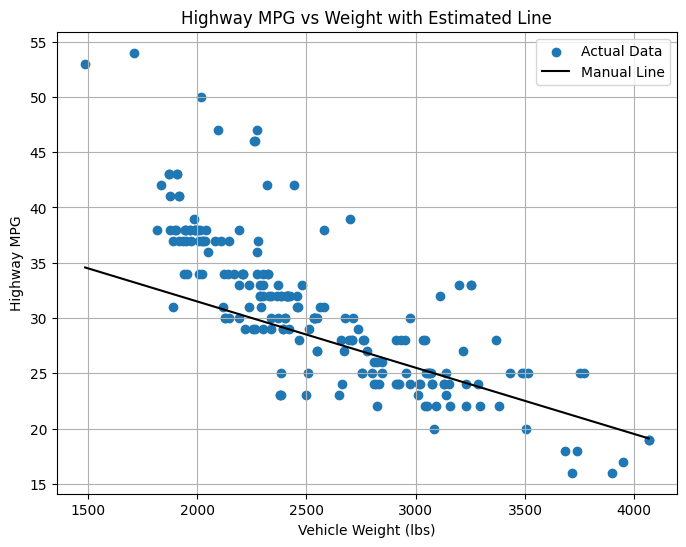

In [62]:
# Estimated slope and intercept from visual inspection
slope_guess = -0.006
intercept_guess = 43.5

# Calculate predicted values for manual line
manual_predictions = slope_guess * x['weight'] + intercept_guess

# Sort weights so the line plots cleanly
sorted_idx = x['weight'].argsort()

# Plot Results
plt.figure(figsize=(8,6))
plt.scatter(x['weight'], y, label="Actual Data")
plt.plot(
    x.iloc[sorted_idx],
    manual_predictions.iloc[sorted_idx],
    color="black",
    label="Manual Line"
)

# Specify Plot Details
plt.xlabel("Vehicle Weight (lbs)")
plt.ylabel("Highway MPG")
plt.title("Highway MPG vs Weight with Estimated Line")
plt.legend()
plt.grid(True)

In [63]:
# Print Estimates
print("Estimated slope:", slope_guess)
print("Estimated intercept:", intercept_guess)

Estimated slope: -0.006
Estimated intercept: 43.5


# **Problem 6**
6. Use Python to find the best-fit (least-squares) line. The Scikit-learn package is a good choice to use
for this.

In [64]:
model = LinearRegression()
model.fit(x, y)

# Extract regression parameters
slope = model.coef_[0]
intercept = model.intercept_

# Print Results
print("Best-fit slope:", slope)
print("Best-fit intercept:", intercept)

Best-fit slope: -0.010547157168719587
Best-fit intercept: 57.70517422574474


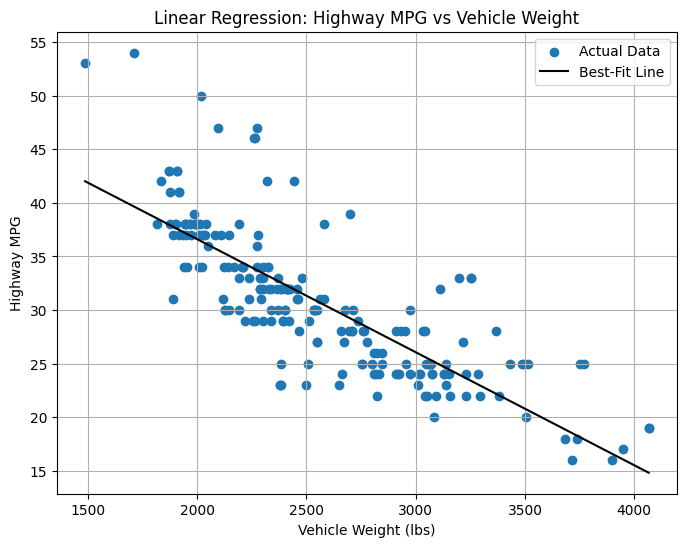

In [65]:
# Generate predictions
best_predictions = model.predict(x)

# Plot Results
plt.figure(figsize=(8,6))
plt.scatter(x['weight'], y, label="Actual Data")
plt.plot(
    x.iloc[sorted_idx],
    best_predictions[sorted_idx],
    color="black",
    label="Best-Fit Line"
)

# Plot Details
plt.xlabel("Vehicle Weight (lbs)")
plt.ylabel("Highway MPG")
plt.title("Linear Regression: Highway MPG vs Vehicle Weight")
plt.legend()
plt.grid(True)

# **Problem 7**
7. Find the root mean squared error (RMSE) of the prediction line you found in problem (5) and the
actual best-fit line found in problem (6). How do these compare? Is this what you would expect?

**Answer**: The RMSE for my manually estimated line was 5.43, while the RMSE for the least-squares regression line was 4.14. This means the best-fit regression model predicts highway mpg more accurately than my visual estimate. That makes sense because the least-squares method is designed to minimize the squared prediction errors across the dataset.


In [66]:
rmse_manual = np.sqrt(np.mean((y.to_numpy() - manual_predictions.to_numpy())**2))
rmse_best = np.sqrt(np.mean((y - best_predictions)**2))

# Print Results
print("Manual RMSE:", rmse_manual)
print("Best-fit RMSE:", rmse_best)

Manual RMSE: 5.42573922219978
Best-fit RMSE: 4.144895442072009


# **Problem 8**
8. Use the best-fit line in problem (6) to predict the highway mpg of a car that weighs 3200 pounds.

**Answer**: Using the best-fit regression model, the predicted highway mpg for a 3200-pound car is around 24 mpg.

In [67]:
# Prediction
predicted_mpg_3200 = model.predict(pd.DataFrame({"weight": [3200]}))

# Print Results
print("Predicted highway mpg for a 3200-pound car:", predicted_mpg_3200[0])

Predicted highway mpg for a 3200-pound car: 23.95427128584206
